In [61]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime as dt
from datetime import timedelta as td
import sys
from pathlib import Path
import os

plt.rcParams['figure.figsize'] = (16,9)

In [68]:
os.chdir(sys.path[0])
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))
os.chdir(sys.path[-1])

In [64]:
from src.data import *

### Preliminaries

In [65]:
memes = ['PEPE', 'MOG', 'FARTCOIN', 'SPX', 'GIGA', 'POPCAT', 'BONK', 'WIF', 'TOSHI', 'BRETT', 'FLOKI', 'FWOG', 'HARRYP']
memes_bin = {'MOG': '1000000MOGUSDT', 'BONK': '1000BONKUSDC', 'FLOKI': '1000FLOKIUSDT', 'PEPE': '1000PEPEUSDC', 'BRETT': 'BRETTUSDT', 'FARTCOIN': 'FARTCOINUSDT', 'POPCAT': 'POPCATUSDT', 'SPX': 'SPXUSDT', 'WIF': 'WIFUSDC'}
memes_byb = {'TOSHI': '1000TOSHIUSDT', 'HARRYP': 'HPOS10IUSDT', 'FWOG': 'FWOGUSDT', 'GIGA': 'GIGAUSDT'}
start_date, end_date = dt(2025, 1, 22, 13), dt(2025, 10, 1, 1)

In [9]:
%%time
for m in memes_bin.keys():
    globals()["df_" + m + "_bin"] = klines_bin(memes_bin[m], start_date, end_date, 'h')

CPU times: total: 875 ms
Wall time: 1min 33s


In [16]:
%%time
for m in memes_byb.keys():
    print(m, dt.now())
    globals()["df_" + m + "_byb"], globals()["df_" + m + "_byb_min"] = klines_byb(memes_byb[m], start_date, end_date)

TOSHI 2026-05-13 08:35:00.629564
HARRYP 2026-05-13 08:44:49.856524
FWOG 2026-05-13 08:50:49.468531
GIGA 2026-05-13 08:59:27.252520
CPU times: total: 5min 31s
Wall time: 31min 37s


### Binance

In [146]:
%%time

time_span = pd.to_datetime(np.arange(start_date - td(days = 10), end_date + td(days = 10), td(days = 1)))

for m in memes_bin.keys():

    print(m, dt.now())
    globals()[m + "_bas"] = pd.DataFrame()
    
    lambdas_a1 = 0
    lambdas_b0 = 0
    lambdas2_a1 = 0
    lambdas2_b0 = 0
    lambdas3_1_a1 = 0
    lambdas3_1_b0 = 0
    lambdas3_2_a1 = 0
    lambdas3_2_b0 = 0
    deltas_a05 = 0
    deltas_b0 = 0
    
    for (ye, mon, day) in pd.Series([(ye, mon, day) for ye, mon, day in zip(time_span.year, time_span.month, time_span.day)]).unique():
        
        str_mon = f"{mon:0{2}d}"
        str_day = f"{day:0{2}d}"
            
        m_tr_id = pd.read_csv("https://data.binance.vision/data/futures/um/daily/aggTrades/" + memes_bin[m] + "/" + memes_bin[m] + "-aggTrades-" + str(ye) + "-" + str_mon + "-" + str_day + ".zip")
        m_tr_id['transact_time'] = pd.to_datetime(m_tr_id['transact_time'], unit = 'ms')
        m_tr_id['price_lag'] = m_tr_id['price'].shift(1)
        m_tr_id['i'] = np.where(m_tr_id['is_buyer_maker'], -1, 1)
        m_tr_id['price_d'] = m_tr_id['price'] - m_tr_id['price_lag']
            
        bs = m_tr_id.loc[(m_tr_id['is_buyer_maker'] == True) & (m_tr_id['is_buyer_maker'].shift(1) == False)]
        bb = m_tr_id.loc[(m_tr_id['is_buyer_maker'] == False) & (m_tr_id['is_buyer_maker'].shift(1) == False)]
        ss = m_tr_id.loc[(m_tr_id['is_buyer_maker'] == True) & (m_tr_id['is_buyer_maker'].shift(1) == True)]
        sb = m_tr_id.loc[(m_tr_id['is_buyer_maker'] == False) & (m_tr_id['is_buyer_maker'].shift(1) == True)]
        s_1 = (-bs['price_d'].mean() + sb['price_d'].mean()) / 2 + (-ss['price_d'].mean() + bb['price_d'].mean()) / 2
        delta = (-ss['price_d'].mean() + bb['price_d'].mean()) / 2 / s_1
            
        bbss = pd.concat([bb, ss])
        bsel = sm.OLS(bbss['price_d'], bbss['i']).fit()
        hsel = sm.OLS((m_tr_id['price_d'] - bsel.params['i'] * m_tr_id['i'].shift(1))[1:], (m_tr_id['i'] - m_tr_id['i'].shift(1))[1:]).fit()
        s_2 = hsel.params['i'] * 2
        lambd = bsel.params['i'] / hsel.params['i']
            
        bssb = m_tr_id.loc[m_tr_id['i'] != m_tr_id['i'].shift(1)][1:]
        s_3_1 = np.sqrt(-(bssb['price_d']).cov(bssb['price_d'].shift(1))) / ((2 - min(lambd, 1)) * 0.5)
        s_3_2 = np.sqrt(-(bssb['price_d']).cov(bssb['price_d'].shift(1))) / (abs(2 - lambd) * 0.5)
        rev_p_d_std = bssb['price_d'].std()
    
        ords = m_tr_id[['transact_time', 'i', 'price', 'quantity']].groupby(['transact_time', 'i'], as_index = False).agg({'price': 'last', 'quantity': 'sum'})
        ords['squantity'] = ords['quantity'] * ords['i']
        ords['price_d'] = ords['price'].diff()
        ords['i_lag'] = ords['i'].shift(1)
        ords['i_d'] = ords['i'] - ords['i_lag']
        ordel = sm.OLS(ords['price_d'][1:], ords[['i', 'squantity']][1:]).fit()
        ordel_2 = sm.OLS(ords['price_d'][1:], ords[['i_d', 'i_lag', 'squantity']][1:]).fit()
        s_4_1 = ordel.params['i'] * 2
        s_4_2 = ordel_2.params['i_d'] * 2
        lambd_2 = ordel_2.params['i_lag'] / ordel_2.params['i_d']

        ordds = m_tr_id[['transact_time', 'i', 'price']].groupby(['transact_time', 'i'], as_index = False).agg({'price': ['first', 'last']})
        ordds['price_d'] = ordds['price']['first'] - ordds['price']['last'].shift(1)
        ordds['i_lag'] = ordds['i'].shift(1)
        ordds['i_d'] = ordds['i'] - ordds['i_lag']
        ordds['i_lag2'] = ordds['i'].shift(2)
        pi = 1 - (ordds['i'] * ordds['i'].shift(1) == 1)[1:].sum() / len(ordds[1:])
        ordds['e_i_lag'] = (1 - 2 * pi) * ordds['i_lag2']
        orddel = sm.OLS(ordds['price_d'][1:], ordds[['i_d', 'i_lag']][1:]).fit()
        orddel_2 = sm.OLS(ordds['price_d'][2:], ordds[['i', 'i_lag', 'e_i_lag']][2:]).fit()
        s_5_1, lambd_3_1 = orddel.params['i_d'] * 2, orddel.params['i_lag'] / orddel.params['i_d']
        s_5_2, lambd_3_2 = orddel_2.params['i'] * 2, orddel_2.params['i_lag'] / orddel_2.params['i'] + 1            
    
        if lambd > 1:
            lambdas_a1 += 1
        elif lambd < 0:
            lambdas_b0 += 1
        if lambd_2 > 1:
            lambdas2_a1 += 1
        elif lambd_2 < 0:
            lambdas2_b0 += 1
        if lambd_3_1 > 1:
            lambdas3_1_a1 += 1
        elif lambd_3_1 < 0:
            lambdas3_1_b0 += 1
        if lambd_3_2 > 1:
            lambdas3_2_a1 += 1
        elif lambd_3_2 < 0:
            lambdas3_2_b0 += 1
        if delta > 0.5:
            deltas_a05 += 1
        elif delta < 0:
            deltas_b0 += 1
            
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_1'] = s_1
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_2'] = s_2
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_3_1'] = s_3_1
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_3_2'] = s_3_2
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_4_1'] = s_4_1
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_4_2'] = s_4_2
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_5_1'] = s_5_1
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_5_2'] = s_5_2
        globals()[m + "_bas"].at[dt(ye, mon, day), 'rev_p_d_std'] = rev_p_d_std
        globals()[m + "_bas"].at[dt(ye, mon, day), 'lambda_1'] = lambd
        globals()[m + "_bas"].at[dt(ye, mon, day), 'lambda_2'] = lambd_2
        globals()[m + "_bas"].at[dt(ye, mon, day), 'lambda_3_1'] = lambd_3_1
        globals()[m + "_bas"].at[dt(ye, mon, day), 'lambda_3_2'] = lambd_3_2
        globals()[m + "_bas"].at[dt(ye, mon, day), 'delta'] = delta
        globals()[m + "_bas"].at[dt(ye, mon, day), 'or_fl_per_1'] = (m_tr_id['i'] * m_tr_id['i'].shift(1) == 1)[1:].sum() / len(m_tr_id[1:])
        globals()[m + "_bas"].at[dt(ye, mon, day), 'or_fl_per_2'] = 1 - pi

    print(m + " lam1 > 1: " + str(lambdas_a1))
    print(m + " lam1 < 0: " + str(lambdas_b0))
    print(m + " lam2 > 1: " + str(lambdas2_a1))
    print(m + " lam2 < 0: " + str(lambdas2_b0))
    print(m + " lam3_1 > 1: " + str(lambdas3_1_a1))
    print(m + " lam3_1 < 0: " + str(lambdas3_1_b0))
    print(m + " lam3_2 > 1: " + str(lambdas3_2_a1))
    print(m + " lam3_2 < 0: " + str(lambdas3_2_b0))
    print(m + " del > 0.5: " + str(deltas_a05))
    print(m + " del < 0: " + str(deltas_b0))

MOG 2026-03-22 23:19:14.627010
MOG lam1 > 1: 12
MOG lam1 < 0: 0
MOG lam2 > 1: 9
MOG lam2 < 0: 0
MOG lam3_1 > 1: 10
MOG lam3_1 < 0: 0
MOG lam3_2 > 1: 14
MOG lam3_2 < 0: 1
MOG del > 0.5: 12
MOG del < 0: 0
BONK 2026-03-22 23:29:12.855202


<timed exec>:44: RuntimeWarning: invalid value encountered in sqrt
<timed exec>:45: RuntimeWarning: invalid value encountered in sqrt
<timed exec>:44: RuntimeWarning: invalid value encountered in sqrt
<timed exec>:45: RuntimeWarning: invalid value encountered in sqrt
<timed exec>:44: RuntimeWarning: invalid value encountered in sqrt
<timed exec>:45: RuntimeWarning: invalid value encountered in sqrt
<timed exec>:44: RuntimeWarning: invalid value encountered in sqrt
<timed exec>:45: RuntimeWarning: invalid value encountered in sqrt
<timed exec>:44: RuntimeWarning: invalid value encountered in sqrt
<timed exec>:45: RuntimeWarning: invalid value encountered in sqrt


BONK lam1 > 1: 243
BONK lam1 < 0: 0
BONK lam2 > 1: 252
BONK lam2 < 0: 0
BONK lam3_1 > 1: 253
BONK lam3_1 < 0: 0
BONK lam3_2 > 1: 254
BONK lam3_2 < 0: 0
BONK del > 0.5: 243
BONK del < 0: 0
FLOKI 2026-03-22 23:39:19.476011
FLOKI lam1 > 1: 194
FLOKI lam1 < 0: 0
FLOKI lam2 > 1: 121
FLOKI lam2 < 0: 0
FLOKI lam3_1 > 1: 143
FLOKI lam3_1 < 0: 0
FLOKI lam3_2 > 1: 134
FLOKI lam3_2 < 0: 0
FLOKI del > 0.5: 196
FLOKI del < 0: 0
PEPE 2026-03-22 23:50:36.046713
PEPE lam1 > 1: 233
PEPE lam1 < 0: 3
PEPE lam2 > 1: 252
PEPE lam2 < 0: 0
PEPE lam3_1 > 1: 254
PEPE lam3_1 < 0: 0
PEPE lam3_2 > 1: 263
PEPE lam3_2 < 0: 0
PEPE del > 0.5: 233
PEPE del < 0: 3
BRETT 2026-03-23 00:02:44.650538
BRETT lam1 > 1: 42
BRETT lam1 < 0: 0
BRETT lam2 > 1: 18
BRETT lam2 < 0: 0
BRETT lam3_1 > 1: 29
BRETT lam3_1 < 0: 0
BRETT lam3_2 > 1: 32
BRETT lam3_2 < 0: 0
BRETT del > 0.5: 42
BRETT del < 0: 0
FARTCOIN 2026-03-23 00:12:14.503601
FARTCOIN lam1 > 1: 15
FARTCOIN lam1 < 0: 0
FARTCOIN lam2 > 1: 2
FARTCOIN lam2 < 0: 0
FARTCOIN lam3_

<timed exec>:44: RuntimeWarning: invalid value encountered in sqrt
<timed exec>:45: RuntimeWarning: invalid value encountered in sqrt
<timed exec>:44: RuntimeWarning: invalid value encountered in sqrt
<timed exec>:45: RuntimeWarning: invalid value encountered in sqrt


WIF lam1 > 1: 268
WIF lam1 < 0: 0
WIF lam2 > 1: 270
WIF lam2 < 0: 0
WIF lam3_1 > 1: 269
WIF lam3_1 < 0: 0
WIF lam3_2 > 1: 270
WIF lam3_2 < 0: 0
WIF del > 0.5: 268
WIF del < 0: 0
CPU times: total: 1h 40min 21s
Wall time: 1h 42min 52s


In [147]:
for m in memes_bin.keys():
    globals()['df_' + m + '_bin']['day'] = globals()['df_' + m + '_bin']['time'].dt.floor('d')
    globals()['df_' + m + '_bin']['pr_dec_pl'] = globals()['df_' + m + '_bin']['close'].astype(str).str.split('.', expand = True)[1].str.len()
    globals()[m + '_bas']['tick_size'] = 10. ** -globals()['df_' + m + '_bin'][['day', 'pr_dec_pl']].groupby('day', as_index = True).max()

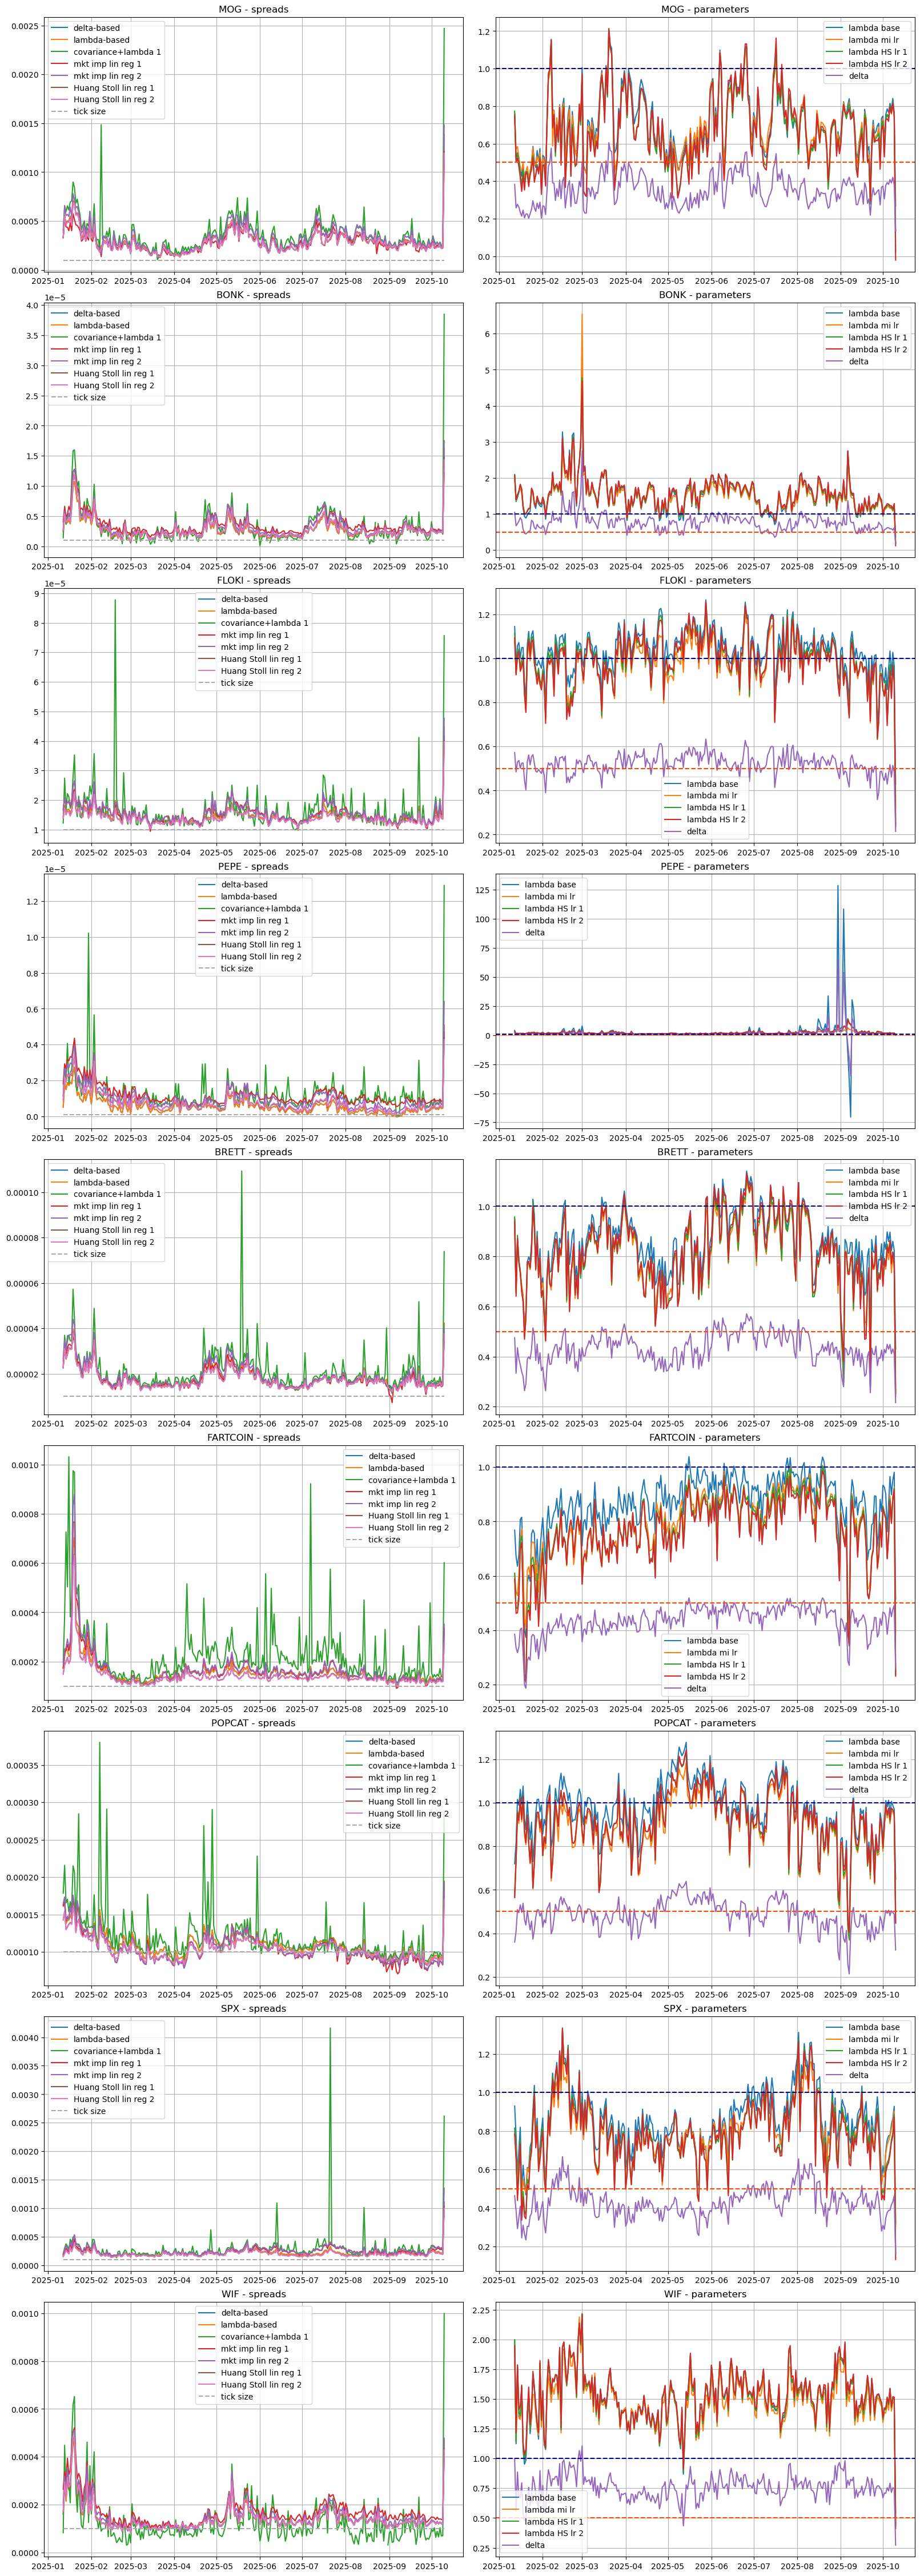

In [148]:
fig, ax = plt.subplots(len(memes_bin), 2, figsize = (16, len(memes_bin) * 5), constrained_layout = True)

for i, m in enumerate(memes_bin):
    
    ax[i, 0].plot(globals()[m + '_bas'][['s_1', 's_2', 's_3_1', 's_4_1', 's_4_2', 's_5_1', 's_5_2']], label = ['delta-based', 'lambda-based', 'covariance+lambda 1', 'mkt imp lin reg 1', 'mkt imp lin reg 2', 'Huang Stoll lin reg 1', 'Huang Stoll lin reg 2'])
    ax[i, 0].plot(globals()[m + '_bas'][['tick_size']], linestyle = '--', c = 'darkgrey', label = 'tick size')
    ax[i, 0].set_title(m + " - spreads")
    ax[i, 0].grid()
    ax[i, 0].legend()

    ax[i, 1].plot(globals()[m + '_bas'][['lambda_1', 'lambda_2', 'lambda_3_1', 'lambda_3_2', 'delta']], label = ['lambda base', 'lambda mi lr', 'lambda HS lr 1', 'lambda HS lr 2', 'delta'])
    ax[i, 1].axhline(0.5, linestyle = '--', c = 'orangered')
    ax[i, 1].axhline(1, linestyle = '--', c = 'darkblue')
    ax[i, 1].set_title(m + " - parameters")
    ax[i, 1].grid()
    ax[i, 1].legend()

plt.show()

In [154]:
for m in memes_bin.keys():
    print(m, globals()[m + '_bas'].isna().sum().sum())

MOG 0
BONK 10
FLOKI 0
PEPE 0
BRETT 0
FARTCOIN 0
POPCAT 0
SPX 0
WIF 4


In [168]:
tcks_bre_bin = pd.DataFrame()
for m in memes_bin.keys():
    for i in list(globals()[m + '_bas'].columns[:8]):
        tcks_bre_bin.at[m, i] = (globals()[m + '_bas'][i] < globals()[m + '_bas']['tick_size']).sum()
tcks_bre_bin = tcks_bre_bin.astype(int)
tcks_bre_bin

,s_1,s_2,s_3_1,s_3_2,s_4_1,s_4_2,s_5_1,s_5_2
MOG,0,0,0,0,0,0,0,0
BONK,1,1,16,3,0,1,1,1
FLOKI,0,0,1,0,2,0,0,0
PEPE,15,15,3,11,0,0,2,2
BRETT,0,0,0,0,1,0,0,0
FARTCOIN,0,0,0,0,4,1,0,0
POPCAT,79,81,62,53,137,138,119,119
SPX,0,0,0,0,0,0,0,0
WIF,10,11,144,1,5,20,15,14


In [170]:
for m in memes_bin.keys():
    print(m, globals()[m + '_bas']['or_fl_per_1'].mean(), globals()[m + '_bas']['or_fl_per_2'].mean())

MOG 0.7748758002996171 0.7021222228401754
BONK 0.7483062538782301 0.6772058321744503
FLOKI 0.7014486630999288 0.6548339213222605
PEPE 0.8372888214157088 0.7239541604833485
BRETT 0.6857374347909362 0.6325900864620678
FARTCOIN 0.6375443566986736 0.560732981484354
POPCAT 0.5683159420229319 0.5380904982359552
SPX 0.7533710167386121 0.6609026628199656
WIF 0.6723446525586037 0.6338618963522521


In [171]:
avg_spreads_bin = pd.DataFrame()
for m in memes_bin.keys():
    for i in list(globals()[m + '_bas'].columns[:8]):
        avg_spreads_bin.at[m, i] = (globals()[m + '_bas'][i] / globals()[m + '_bas']['tick_size']).mean()
avg_spreads_bin

,s_1,s_2,s_3_1,s_3_2,s_4_1,s_4_2,s_5_1,s_5_2
MOG,2.940276,2.935580,3.676105,3.684562,2.826942,3.296317,2.845419,2.846879
BONK,2.664855,2.663336,3.308897,9.949974,3.650878,3.262292,2.850340,2.867245
FLOKI,1.450996,1.448671,1.610309,1.707292,1.542570,1.555251,1.383001,1.379759
PEPE,5.556948,5.554903,12.247047,34.746266,12.010488,9.943537,7.225697,7.407442
BRETT,1.821859,1.816613,2.133815,2.146052,1.791500,1.903266,1.742425,1.747351
FARTCOIN,1.589992,1.587355,2.269584,2.271210,1.627811,1.674688,1.425147,1.415111
POPCAT,1.099147,1.095819,1.204778,1.256304,1.038894,1.044907,1.033547,1.035403
SPX,2.144590,2.143877,2.948453,2.994433,2.360199,2.538520,2.017356,2.009908
WIF,1.423535,1.422461,1.259068,3.697220,1.707158,1.531208,1.425529,1.430762


### ByBit

In [172]:
%%time

time_span = pd.to_datetime(np.arange(start_date - td(days = 10), end_date + td(days = 10), td(days = 1)))

for m in memes_byb.keys():

    print(m, dt.now())
    globals()[m + "_bas"] = pd.DataFrame()
    
    lambdas_a1, lambdas_b0 = 0, 0
    lambdas2_a1, lambdas2_b0 = 0, 0
    lambdas3_1_a1, lambdas3_1_b0 = 0, 0
    lambdas3_2_a1, lambdas3_2_b0 = 0, 0
    deltas_a05, deltas_b0 = 0, 0
    
    for (ye, mon, day) in pd.Series([(ye, mon, day) for ye, mon, day in zip(time_span.year, time_span.month, time_span.day)]).unique():
        
        str_mon = f"{mon:0{2}d}"
        str_day = f"{day:0{2}d}"
            
        m_tr_id = pd.read_csv("https://public.bybit.com/trading/" + memes_byb[m] + "/" + memes_byb[m] + str(ye) + "-" + str_mon + "-" + str_day + ".csv.gz")
        m_tr_id['timestamp'] = pd.to_datetime(m_tr_id['timestamp'], unit = 's')
        m_tr_id['price_lag'] = m_tr_id['price'].shift(1)
        m_tr_id['i'] = np.where(m_tr_id['side'] == "Sell", -1, 1)
        m_tr_id['price_d'] = m_tr_id['price'] - m_tr_id['price_lag']
        
        bs = m_tr_id.loc[(m_tr_id['i'] == -1) & (m_tr_id['i'].shift(1) == 1)]
        bb = m_tr_id.loc[(m_tr_id['i'] == 1) & (m_tr_id['i'].shift(1) == 1)]
        ss = m_tr_id.loc[(m_tr_id['i'] == -1) & (m_tr_id['i'].shift(1) == -1)]
        sb = m_tr_id.loc[(m_tr_id['i'] == 1) & (m_tr_id['i'].shift(1) == -1)]
        s_1 = (-bs['price_d'].mean() + sb['price_d'].mean()) / 2 + (-ss['price_d'].mean() + bb['price_d'].mean()) / 2
        delta = (-ss['price_d'].mean() + bb['price_d'].mean()) / 2 / s_1
        
        bbss = pd.concat([bb, ss])
        bsel = sm.OLS(bbss['price_d'], bbss['i']).fit()
        hsel = sm.OLS((m_tr_id['price_d'] - bsel.params['i'] * m_tr_id['i'].shift(1))[1:], (m_tr_id['i'] - m_tr_id['i'].shift(1))[1:]).fit()
        s_2 = hsel.params['i'] * 2
        lambd = bsel.params['i'] / hsel.params['i']
        
        bssb = m_tr_id.loc[m_tr_id['i'] != m_tr_id['i'].shift(1)][1:]
        s_3_1 = np.sqrt(-(bssb['price_d']).cov(bssb['price_d'].shift(1))) / ((2 - min(lambd, 1)) * 0.5)
        s_3_2 = np.sqrt(-(bssb['price_d']).cov(bssb['price_d'].shift(1))) / (abs(2 - lambd) * 0.5)
        rev_p_d_std = bssb['price_d'].std()

        ords = m_tr_id[['timestamp', 'i', 'price', 'size']].groupby(['timestamp', 'i'], as_index = False).agg({'price': 'last', 'size': 'sum'})
        ords['squantity'] = ords['size'] * ords['i']
        ords['price_d'] = ords['price'].diff()
        ords['i_lag'] = ords['i'].shift(1)
        ords['i_d'] = ords['i'] - ords['i_lag']
        ordel = sm.OLS(ords['price_d'][1:], ords[['i', 'squantity']][1:]).fit()
        ordel_2 = sm.OLS(ords['price_d'][1:], ords[['i_d', 'i_lag', 'squantity']][1:]).fit()
        s_4_1 = ordel.params['i'] * 2
        s_4_2 = ordel_2.params['i_d'] * 2
        lambd_2 = ordel_2.params['i_lag'] / ordel_2.params['i_d']

        ordds = m_tr_id[['timestamp', 'i', 'price']].groupby(['timestamp', 'i'], as_index = False).agg({'price': ['first', 'last']})
        ordds['price_d'] = ordds['price']['first'] - ordds['price']['last'].shift(1)
        ordds['i_lag'] = ordds['i'].shift(1)
        ordds['i_d'] = ordds['i'] - ordds['i_lag']
        ordds['i_lag2'] = ordds['i'].shift(2)
        pi = 1 - (ordds['i'] * ordds['i'].shift(1) == 1)[1:].sum() / len(ordds[1:])
        ordds['e_i_lag'] = (1 - 2 * pi) * ordds['i_lag2']
        orddel = sm.OLS(ordds['price_d'][1:], ordds[['i_d', 'i_lag']][1:]).fit()
        orddel_2 = sm.OLS(ordds['price_d'][2:], ordds[['i', 'i_lag', 'e_i_lag']][2:]).fit()
        s_5_1, lambd_3_1 = orddel.params['i_d'] * 2, orddel.params['i_lag'] / orddel.params['i_d']
        s_5_2, lambd_3_2 = orddel_2.params['i'] * 2, orddel_2.params['i_lag'] / orddel_2.params['i'] + 1            

        if lambd > 1:
            lambdas_a1 += 1
        elif lambd < 0:
            lambdas_b0 += 1
        if lambd_2 > 1:
            lambdas2_a1 += 1
        elif lambd_2 < 0:
            lambdas2_b0 += 1
        if lambd_3_1 > 1:
            lambdas3_1_a1 += 1
        elif lambd_3_1 < 0:
            lambdas3_1_b0 += 1
        if lambd_3_2 > 1:
            lambdas3_2_a1 += 1
        elif lambd_3_2 < 0:
            lambdas3_2_b0 += 1
        if delta > 0.5:
            deltas_a05 += 1
        elif delta < 0:
            deltas_b0 += 1
        
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_1'] = s_1
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_2'] = s_2
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_3_1'] = s_3_1
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_3_2'] = s_3_2
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_4_1'] = s_4_1
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_4_2'] = s_4_2
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_5_1'] = s_5_1
        globals()[m + "_bas"].at[dt(ye, mon, day), 's_5_2'] = s_5_2
        globals()[m + "_bas"].at[dt(ye, mon, day), 'rev_p_d_std'] = rev_p_d_std
        globals()[m + "_bas"].at[dt(ye, mon, day), 'lambda_1'] = lambd
        globals()[m + "_bas"].at[dt(ye, mon, day), 'lambda_2'] = lambd_2
        globals()[m + "_bas"].at[dt(ye, mon, day), 'lambda_3_1'] = lambd_3_1
        globals()[m + "_bas"].at[dt(ye, mon, day), 'lambda_3_2'] = lambd_3_2
        globals()[m + "_bas"].at[dt(ye, mon, day), 'delta'] = delta
        globals()[m + "_bas"].at[dt(ye, mon, day), 'or_fl_per_1'] = (m_tr_id['i'] * m_tr_id['i'].shift(1) == 1)[1:].sum() / len(m_tr_id[1:])
        globals()[m + "_bas"].at[dt(ye, mon, day), 'or_fl_per_2'] = 1 - pi

    print(m + " lam1 > 1: " + str(lambdas_a1))
    print(m + " lam1 < 0: " + str(lambdas_b0))
    print(m + " lam2 > 1: " + str(lambdas2_a1))
    print(m + " lam2 < 0: " + str(lambdas2_b0))
    print(m + " lam3_1 > 1: " + str(lambdas3_1_a1))
    print(m + " lam3_1 < 0: " + str(lambdas3_1_b0))
    print(m + " lam3_2 > 1: " + str(lambdas3_2_a1))
    print(m + " lam3_2 < 0: " + str(lambdas3_2_b0))
    print(m + " del > 0.5: " + str(deltas_a05))
    print(m + " del < 0: " + str(deltas_b0))

TOSHI 2026-03-23 02:32:26.717530
TOSHI lam1 > 1: 6
TOSHI lam1 < 0: 0
TOSHI lam2 > 1: 8
TOSHI lam2 < 0: 0
TOSHI lam3_1 > 1: 12
TOSHI lam3_1 < 0: 7
TOSHI lam3_2 > 1: 12
TOSHI lam3_2 < 0: 10
TOSHI del > 0.5: 6
TOSHI del < 0: 0
HARRYP 2026-03-23 02:38:04.744133
HARRYP lam1 > 1: 9
HARRYP lam1 < 0: 0
HARRYP lam2 > 1: 0
HARRYP lam2 < 0: 0
HARRYP lam3_1 > 1: 7
HARRYP lam3_1 < 0: 24
HARRYP lam3_2 > 1: 7
HARRYP lam3_2 < 0: 22
HARRYP del > 0.5: 9
HARRYP del < 0: 0
FWOG 2026-03-23 02:40:51.138343
FWOG lam1 > 1: 1
FWOG lam1 < 0: 1
FWOG lam2 > 1: 2
FWOG lam2 < 0: 0
FWOG lam3_1 > 1: 3
FWOG lam3_1 < 0: 1
FWOG lam3_2 > 1: 2
FWOG lam3_2 < 0: 1
FWOG del > 0.5: 1
FWOG del < 0: 1
GIGA 2026-03-23 02:45:17.969647
GIGA lam1 > 1: 0
GIGA lam1 < 0: 0
GIGA lam2 > 1: 0
GIGA lam2 < 0: 0
GIGA lam3_1 > 1: 0
GIGA lam3_1 < 0: 0
GIGA lam3_2 > 1: 0
GIGA lam3_2 < 0: 0
GIGA del > 0.5: 0
GIGA del < 0: 0
CPU times: total: 32min 15s
Wall time: 16min 17s


In [173]:
for m in memes_byb.keys():
    globals()['df_' + m + '_byb']['day'] = pd.Series(globals()['df_' + m + '_byb'].index, index = globals()['df_' + m + '_byb'].index).dt.floor('d')
    globals()['df_' + m + '_byb']['pr_dec_pl'] = globals()['df_' + m + '_byb']['close'].astype(str).str.split('.', expand = True)[1].str.len()
    globals()[m + '_bas']['tick_size'] = 10. ** -globals()['df_' + m + '_byb'][['day', 'pr_dec_pl']].groupby('day', as_index = True).max()

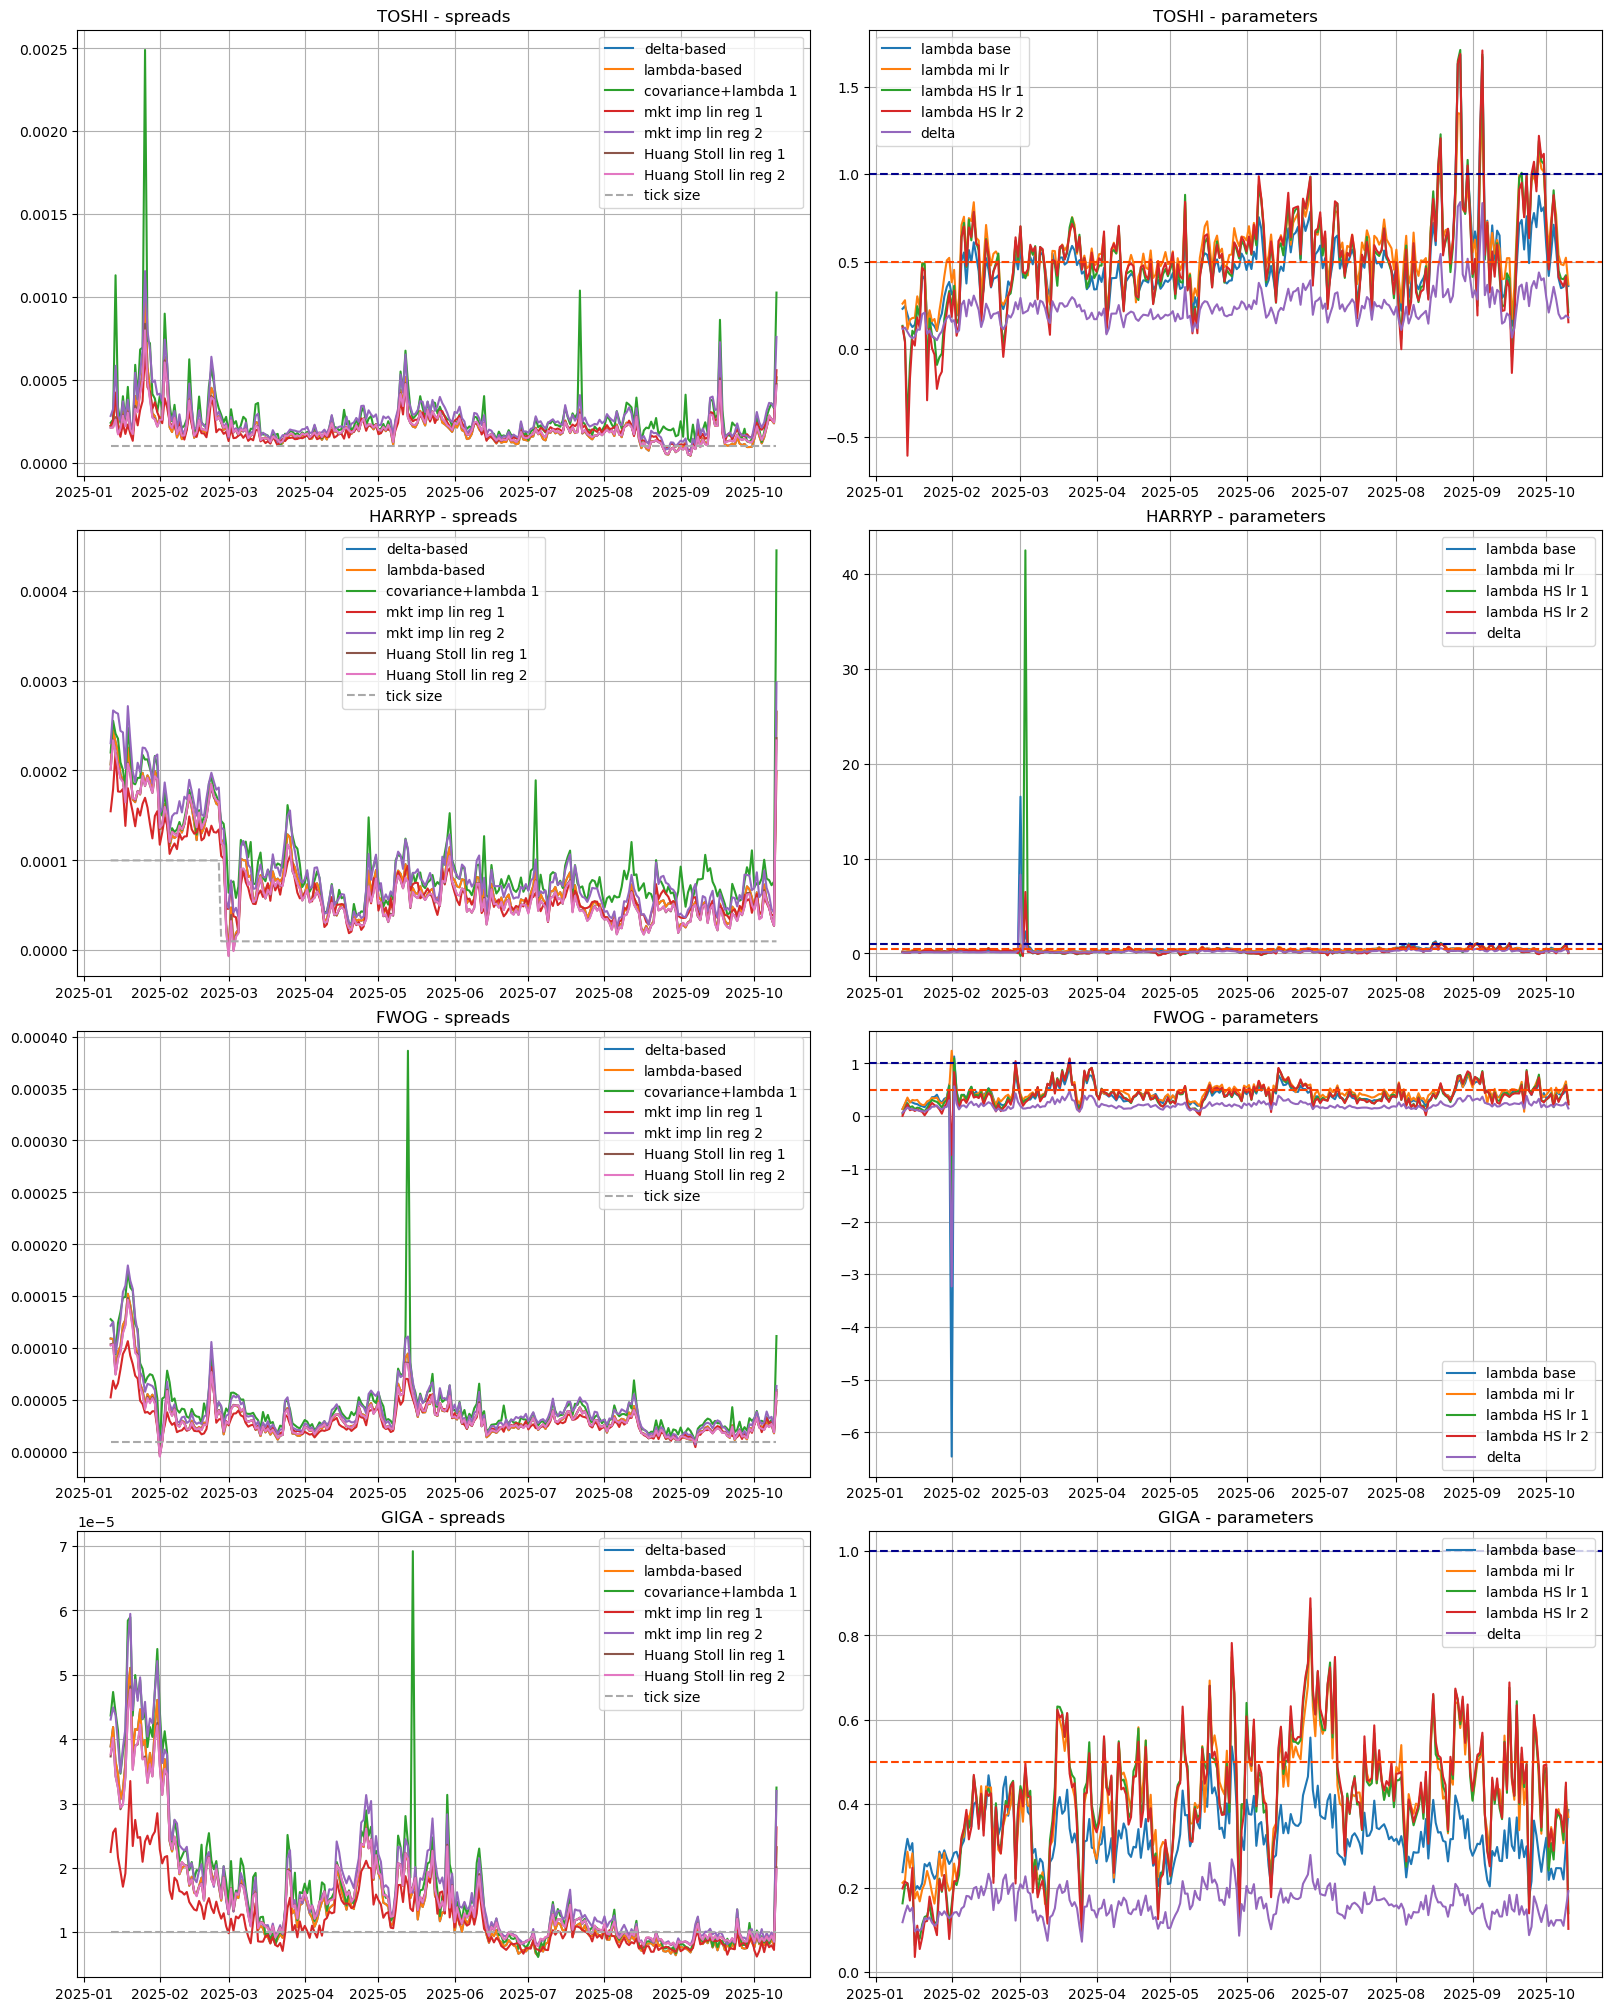

In [174]:
fig, ax = plt.subplots(len(memes_byb), 2, figsize = (16, len(memes_byb) * 5), constrained_layout = True)

for i, m in enumerate(memes_byb):
    
    ax[i, 0].plot(globals()[m + '_bas'][['s_1', 's_2', 's_3_1', 's_4_1', 's_4_2', 's_5_1', 's_5_2']], label = ['delta-based', 'lambda-based', 'covariance+lambda 1', 'mkt imp lin reg 1', 'mkt imp lin reg 2', 'Huang Stoll lin reg 1', 'Huang Stoll lin reg 2'])
    ax[i, 0].plot(globals()[m + '_bas'][['tick_size']], linestyle = '--', c = 'darkgrey', label = 'tick size')
    ax[i, 0].set_title(m + " - spreads")
    ax[i, 0].grid()
    ax[i, 0].legend()

    ax[i, 1].plot(globals()[m + '_bas'][['lambda_1', 'lambda_2', 'lambda_3_1', 'lambda_3_2', 'delta']], label = ['lambda base', 'lambda mi lr', 'lambda HS lr 1', 'lambda HS lr 2', 'delta'])
    ax[i, 1].axhline(0.5, linestyle = '--', c = 'orangered')
    ax[i, 1].axhline(1, linestyle = '--', c = 'darkblue')
    ax[i, 1].set_title(m + " - parameters")
    ax[i, 1].grid()
    ax[i, 1].legend()

plt.show()

In [175]:
for m in memes_byb.keys():
    print(m, globals()[m + '_bas'].isna().sum().sum())

TOSHI 0
HARRYP 0
FWOG 0
GIGA 0


In [176]:
tcks_bre_byb = pd.DataFrame()
for m in memes_byb.keys():
    for i in list(globals()[m + '_bas'].columns[:8]):
        tcks_bre_byb.at[m, i] = (globals()[m + '_bas'][i] < globals()[m + '_bas']['tick_size']).sum()
tcks_bre_byb = tcks_bre_byb.astype(int)
tcks_bre_byb

,s_1,s_2,s_3_1,s_3_2,s_4_1,s_4_2,s_5_1,s_5_2
TOSHI,17,17,0,0,6,4,15,16
HARRYP,2,2,0,1,0,0,2,2
FWOG,2,2,1,1,1,2,2,3
GIGA,105,105,87,87,124,68,87,87


In [177]:
for m in memes_byb.keys():
    print(m, globals()[m + '_bas']['or_fl_per_1'].mean(), globals()[m + '_bas']['or_fl_per_2'].mean())

TOSHI 0.8809408073549798 0.7261644917464903
HARRYP 0.8625152795810588 0.6851225602329842
FWOG 0.8658026584046458 0.7133802807523987
GIGA 0.8647411341860682 0.6951985345531809


In [179]:
avg_spreads_byb = pd.DataFrame()
for m in memes_byb.keys():
    for i in list(globals()[m + '_bas'].columns[:8]):
        avg_spreads_byb.at[m, i] = (globals()[m + '_bas'][i] / globals()[m + '_bas']['tick_size']).mean()
avg_spreads_byb

,s_1,s_2,s_3_1,s_3_2,s_4_1,s_4_2,s_5_1,s_5_2
TOSHI,2.037901,2.037411,2.782901,2.823294,2.041847,2.652209,2.052498,2.045411
HARRYP,5.067872,5.065731,7.007319,7.069195,4.819568,6.330120,4.608448,4.600711
FWOG,3.339785,3.339041,4.394156,4.397066,2.972033,4.079285,3.303580,3.286824
GIGA,1.477827,1.477356,1.680385,1.680385,1.219402,1.694629,1.523036,1.522244


### Final bid-ask spread time series

In [180]:
for m in memes_bin.keys():
    globals()[m + '_bas']['s_fl'] = globals()[m + '_bas'][['s_5_1', 'tick_size']].max(axis = 1)
    globals()[m + '_bas']['s_fin'] = globals()[m + '_bas']['s_fl'].rolling(window = 5, win_type = "triang", center = True).mean()
for m in memes_byb.keys():
    globals()[m + '_bas']['s_fl'] = globals()[m + '_bas'][['s_5_1', 'tick_size']].max(axis = 1)
    globals()[m + '_bas']['s_fin'] = globals()[m + '_bas']['s_fl'].rolling(window = 5, win_type = "triang", center = True).mean()

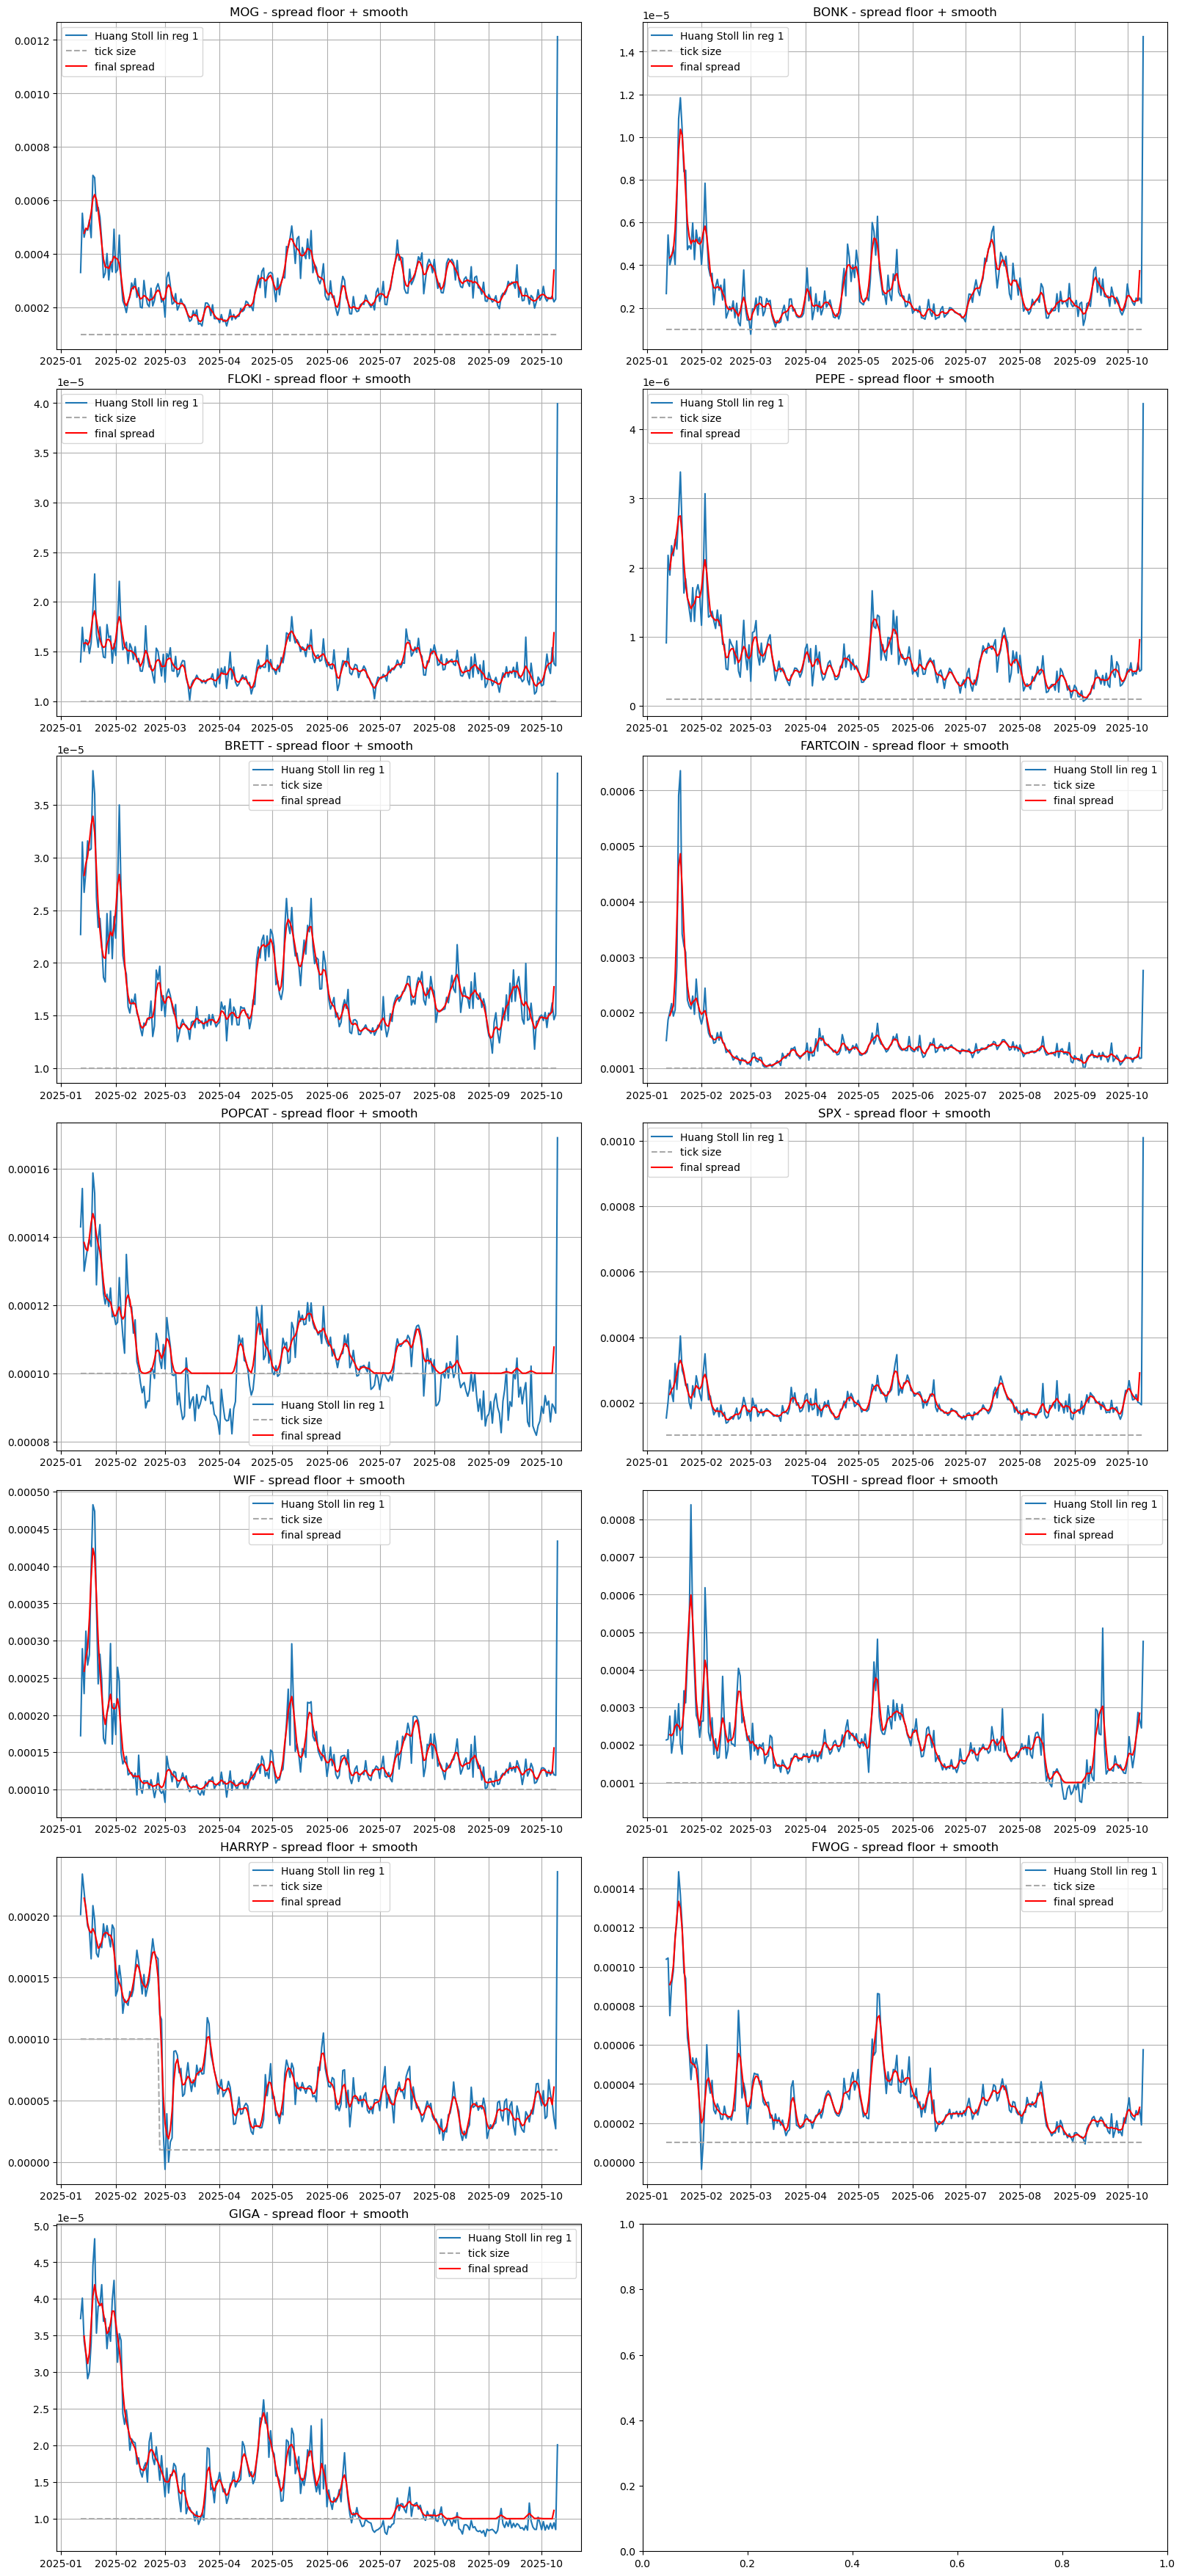

In [181]:
n_ro = int(np.ceil((len(memes_bin) + len(memes_byb)) / 2))
fig, ax = plt.subplots(n_ro, 2, figsize = (16, n_ro * 5), constrained_layout = True)

for i, m in enumerate(memes_bin):
    ax[i // 2, i % 2].plot(globals()[m + '_bas']['s_5_1'], label = 'Huang Stoll lin reg 1')
    ax[i // 2, i % 2].plot(globals()[m + '_bas']['tick_size'], linestyle = '--', c = 'darkgrey', label = 'tick size')
    ax[i // 2, i % 2].plot(globals()[m + '_bas']['s_fin'], c = 'r', label = 'final spread')
    ax[i // 2, i % 2].set_title(m + " - spread floor + smooth")
    ax[i // 2, i % 2].grid()
    ax[i // 2, i % 2].legend()

for i, m in enumerate(memes_byb):
    j = i + len(memes_bin)
    ax[j // 2, j % 2].plot(globals()[m + '_bas']['s_5_1'], label = 'Huang Stoll lin reg 1')
    ax[j // 2, j % 2].plot(globals()[m + '_bas']['tick_size'], linestyle = '--', c = 'darkgrey', label = 'tick size')
    ax[j // 2, j % 2].plot(globals()[m + '_bas']['s_fin'], c = 'r', label = 'final spread')
    ax[j // 2, j % 2].set_title(m + " - spread floor + smooth")
    ax[j // 2, j % 2].grid()
    ax[j // 2, j % 2].legend()

plt.show()

In [182]:
df_bas_2501_2509 = pd.DataFrame(index = globals()['df_' + m + '_byb'][(start_date - td(hours = 1)):(end_date - td(hours = 2))].index)
df_bas_2501_2509['day'] = pd.Series(df_bas_2501_2509.index, index = df_bas_2501_2509.index).dt.floor('d')
for m in memes_bin.keys():
    df_bas_2501_2509 = df_bas_2501_2509.merge(globals()[m + '_bas'][['s_fin']], how = "left", left_on = 'day', right_index = True).rename(columns = {'s_fin': m})
for m in memes_byb.keys():
    df_bas_2501_2509 = df_bas_2501_2509.merge(globals()[m + '_bas'][['s_fin']], how = "left", left_on = 'day', right_index = True).rename(columns = {'s_fin': m})
df_bas_2501_2509.drop(columns = 'day', inplace = True)

In [183]:
df_bas_2501_2509 = df_bas_2501_2509[memes]

In [184]:
df_bas_2501_2509.to_csv('intermediate_output/df_bas_2501_2509.csv', index = True)

In [26]:
df_bas = pd.read_csv('intermediate_output/df_bas_2501_2509.csv').set_index('time')
df_bas.index = pd.to_datetime(df_bas.index)